# Telco Customer Churn — Prédiction du churn

Pipeline ML de bout en bout : nettoyage → EDA → preprocessing anti-fuite → modélisation
(régression logistique vs XGBoost) → évaluation orientée *recall* → interprétabilité SHAP →
déploiement FastAPI. Décisions et justifications : voir `cahier des charges.md`.

## 1. Chargement des données

In [1]:
import pandas as pd

# Définition des données d'analyse
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())
df.info()
print(df["Churn"].value_counts(normalize=True))

# Identification des lignes problématiques avant nettoyage
mask_bad = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(f"Lignes avec TotalCharges non convertible : {mask_bad.sum()}")
df.loc[mask_bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


## 2. Nettoyage

`TotalCharges` est typée `str` : 11 cellules vides, **toutes des clients `tenure = 0`** (jamais facturés). On convertit en numérique puis on impute **0** sur ces lignes — la valeur manquante a une **cause logique identifiée** (zéro mois ⇒ zéro facturé), pas une approximation arbitraire.

Ces deux opérations sont **déterministes** (aucun paramètre appris sur la distribution), donc applicables avant le split sans fuite ; l'imputation *statistique* reste, elle, dans les pipelines (`fit` par fold, §4). `customerID` est écarté des features en §4. Contrôle des doublons exacts au passage.

In [2]:
# Section 2 — Nettoyage
# TotalCharges : str -> numérique. Les 11 cellules vides deviennent NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Garde-fou : tout NaN généré doit être un client tenure=0 (cause logique identifiée).
# Si un NaN apparaissait ailleurs, l'imputation à 0 ne serait plus justifiée.
nan_idx = df["TotalCharges"].isna()
assert (df.loc[nan_idx, "tenure"] == 0).all(), "NaN TotalCharges hors tenure=0 : a investiguer"

# Règle métier : 0 mois d'ancienneté => 0 facturé. Imputation déterministe (pas de fuite).
df.loc[df["tenure"] == 0, "TotalCharges"] = 0.0

# Doublons exacts (ligne entière, customerID compris) : anomalie de collecte éventuelle.
n_dupes = int(df.duplicated().sum())

print("TotalCharges dtype       :", df["TotalCharges"].dtype)
print("NaN TotalCharges restants:", int(df["TotalCharges"].isna().sum()))
print("Clients tenure=0 -> 0    :", int((df["tenure"] == 0).sum()))
print("Doublons exacts          :", n_dupes)
print("Shape (inchangee)        :", df.shape)

TotalCharges dtype       : float64
NaN TotalCharges restants: 0
Clients tenure=0 -> 0    : 11
Doublons exacts          : 0
Shape (inchangee)        : (7043, 21)


## 3. Analyse exploratoire (EDA)

Analyse **descriptive** sur le jeu nettoyé complet (`df`) : aucun paramètre appris, aucune feature créée ou supprimée → pas de fuite, et le split (§4) reste la frontière des transformations apprenantes. L'analyse des **interactions** est reportée à l'interprétabilité **SHAP** (plus loin), comme prévu au cahier.

- **3.1 Catégorielles** — taux de churn par modalité + test du **Chi²**. Avec n = 7043 presque tout ressort « significatif » : on classe donc par **V de Cramér** (taille d'effet), pas par p-value.
- **3.2 Numériques** (`tenure`, `MonthlyCharges`, `TotalCharges`) — distributions par classe, corrélations, détection formalisée des outliers (règle IQR de Tukey).
- **3.3 Synthèse** — insights business pour le README.

         feature  modalites  cramers_v   chi2  p_value
        Contract          3      0.410 1184.6 5.9e-258
  OnlineSecurity          3      0.347  850.0 2.7e-185
     TechSupport          3      0.343  828.2 1.4e-180
 InternetService          3      0.322  732.3 9.6e-160
   PaymentMethod          4      0.303  648.1 3.7e-140
    OnlineBackup          3      0.292  601.8 2.1e-131
DeviceProtection          3      0.281  558.4 5.5e-122
 StreamingMovies          3      0.230  375.7  2.7e-82
     StreamingTV          3      0.230  374.2  5.5e-82
PaperlessBilling          2      0.191  258.3  4.1e-58
      Dependents          2      0.163  189.1  4.9e-43
         Partner          2      0.150  158.7  2.1e-36
   MultipleLines          3      0.036   11.3  3.5e-03
    PhoneService          2      0.000    0.9  3.4e-01
          gender          2      0.000    0.5  4.9e-01


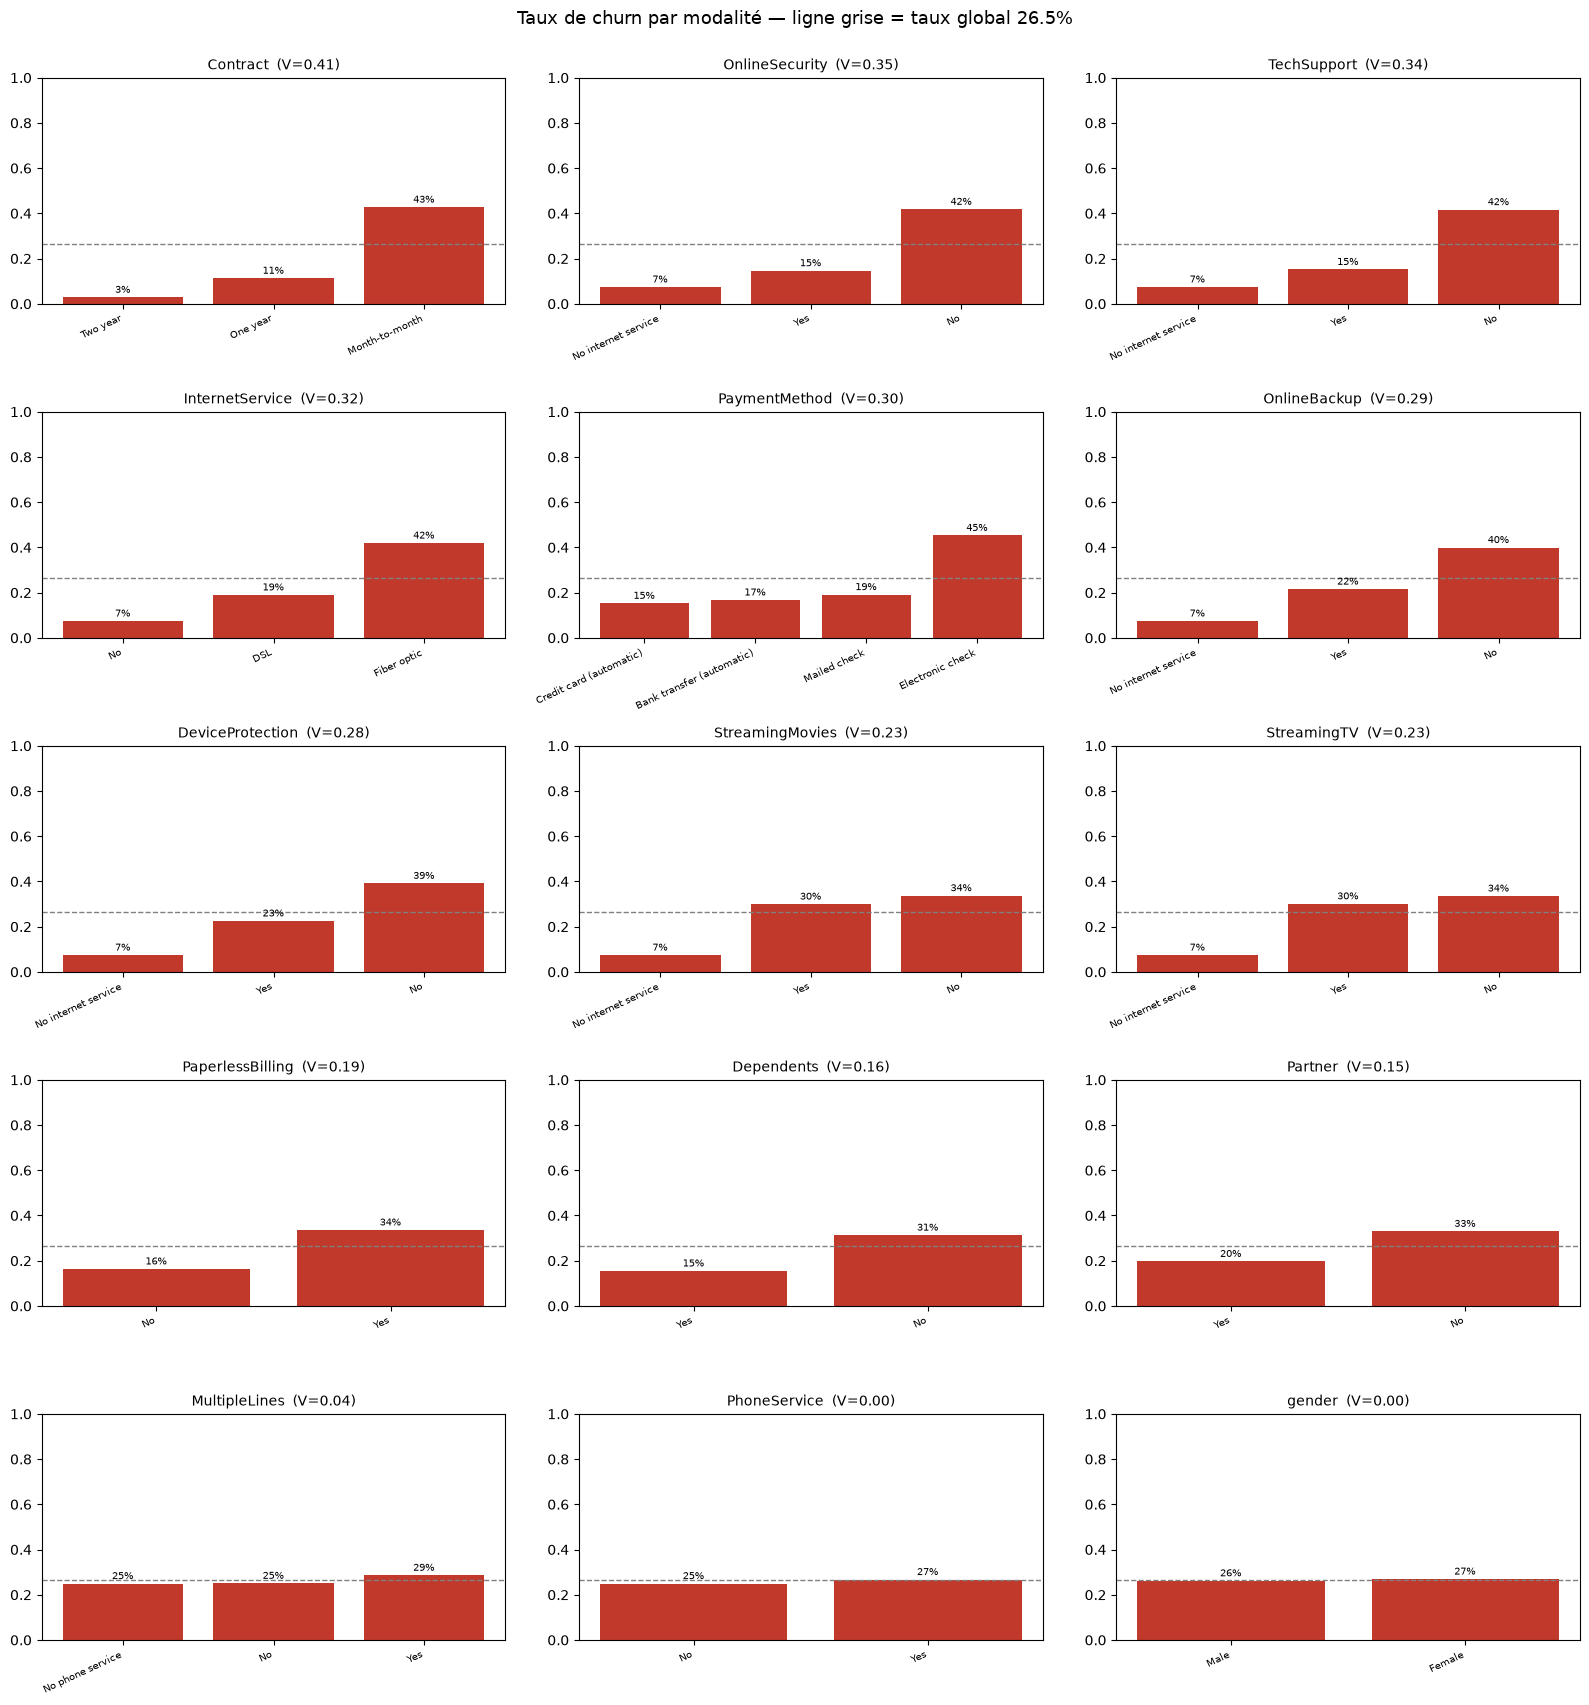

In [3]:
# 3.1 — Catégorielles : association avec le churn (Chi² + V de Cramér), puis visualisation
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Catégorielles = non-numériques hors id/cible. exclude="number" écarte SeniorCitizen (0/1,
# numérique au cahier) et évite l'ambiguïté object/str de pandas 3.
cat_cols = df.drop(columns=["customerID", "Churn"]).select_dtypes(exclude="number").columns.tolist()
churn = (df["Churn"] == "Yes").astype(int)
global_rate = churn.mean()

def cramers_v(confusion):
    """V de Cramér corrigé du biais (Bergsma 2013) : taille d'effet dans [0, 1]."""
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.to_numpy().sum()
    r, k = confusion.shape
    phi2corr = max(0, chi2 / n - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

rows = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df["Churn"])
    chi2, p, _, _ = chi2_contingency(ct)
    rows.append({"feature": col, "modalites": df[col].nunique(),
                 "cramers_v": round(cramers_v(ct), 3), "chi2": round(chi2, 1), "p_value": p})

chi2_table = pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
print(chi2_table.assign(p_value=chi2_table["p_value"].map("{:.1e}".format)).to_string(index=False))

# Taux de churn par modalité — panneaux ordonnés par V de Cramér décroissant
ordered = chi2_table["feature"].tolist()
nrows = -(-len(ordered) // 3)
fig, axes = plt.subplots(nrows, 3, figsize=(16, 3.4 * nrows))
axes = axes.ravel()
for ax, col in zip(axes, ordered):
    rate = churn.groupby(df[col]).mean().sort_values()
    ax.bar(range(len(rate)), rate.values, color="#c0392b")
    ax.axhline(global_rate, color="grey", ls="--", lw=1)
    ax.set_xticks(range(len(rate)), rate.index.astype(str), rotation=25, ha="right", fontsize=7)
    v = chi2_table.loc[chi2_table["feature"] == col, "cramers_v"].iat[0]
    ax.set_title(f"{col}  (V={v:.2f})", fontsize=10)
    ax.set_ylim(0, 1)
    for i, val in enumerate(rate.values):
        ax.text(i, val + 0.02, f"{val:.0%}", ha="center", fontsize=7)
for ax in axes[len(ordered):]:
    ax.set_visible(False)
fig.suptitle(f"Taux de churn par modalité — ligne grise = taux global {global_rate:.1%}", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

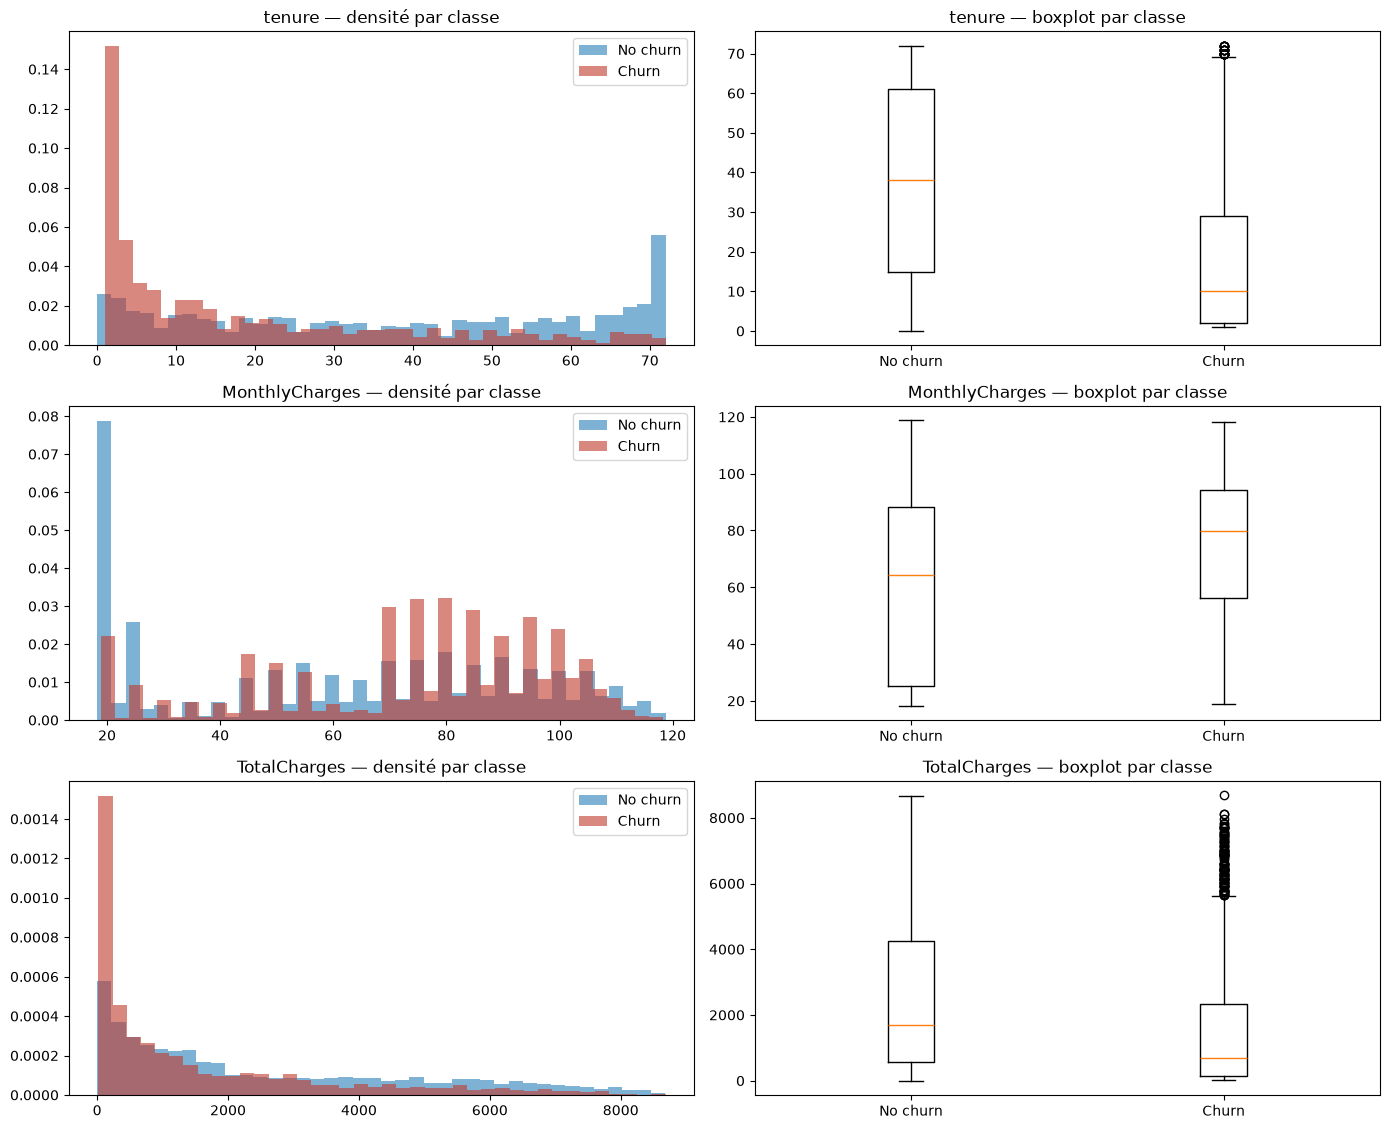

In [4]:
# 3.2 — Numériques : distributions par classe (No churn vs Churn)
num_cont = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(len(num_cont), 2, figsize=(14, 3.8 * len(num_cont)))
for i, col in enumerate(num_cont):
    axes[i, 0].hist(df.loc[churn == 0, col], bins=40, density=True, alpha=0.6,
                    color="#2980b9", label="No churn")
    axes[i, 0].hist(df.loc[churn == 1, col], bins=40, density=True, alpha=0.6,
                    color="#c0392b", label="Churn")
    axes[i, 0].set_title(f"{col} — densité par classe")
    axes[i, 0].legend()

    axes[i, 1].boxplot([df.loc[churn == 0, col], df.loc[churn == 1, col]])
    axes[i, 1].set_xticks([1, 2], ["No churn", "Churn"])
    axes[i, 1].set_title(f"{col} — boxplot par classe")

fig.tight_layout()
plt.show()

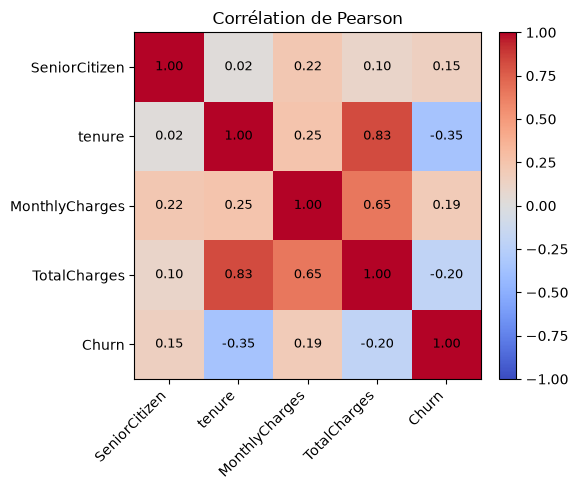

       feature    Q1     Q3  borne_basse  borne_haute  n_outliers   pct
        tenure   9.0   55.0        -60.0        124.0           0 0.00%
MonthlyCharges  35.5   89.8        -46.0        171.4           0 0.00%
  TotalCharges 398.6 3786.6      -4683.5       8868.7           0 0.00%


In [5]:
# 3.2 — Corrélations (numériques + cible) et détection formalisée des outliers (IQR)
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
corr = df[corr_cols].assign(Churn=churn).corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Corrélation de Pearson")
fig.tight_layout()
plt.show()

# Outliers : règle IQR de Tukey (k = 1.5). On les détecte et quantifie, on ne les supprime pas
# (valeurs métier plausibles ; XGBoost y est robuste, la LR passe par un StandardScaler).
num_cont = ["tenure", "MonthlyCharges", "TotalCharges"]
out_rows = []
for col in num_cont:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < low) | (df[col] > high)).sum())
    out_rows.append({"feature": col, "Q1": round(q1, 1), "Q3": round(q3, 1),
                     "borne_basse": round(low, 1), "borne_haute": round(high, 1),
                     "n_outliers": n_out, "pct": f"{n_out / len(df):.2%}"})
print(pd.DataFrame(out_rows).to_string(index=False))

### 3.3 Synthèse — insights business

1. **L'engagement contractuel domine.** `Contract` est le 1er facteur (V de Cramér = 0.41) : le *month-to-month* churne très au-dessus de la moyenne, les contrats 1–2 ans très en dessous. Levier de rétention n°1.
2. **Le bloc sécurité/support pèse.** L'absence d'`OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection` (V ≈ 0.28–0.35) est associée à un sur-churn. Piste produit : bundles de fidélisation.
3. **Profil de facturation à risque.** `Fiber optic`, `Electronic check` et `Paperless billing` concentrent le churn ; côté numérique, **faible `tenure`** et **`MonthlyCharges` élevées** sont les marqueurs les plus nets (cf. 3.2). Cible prioritaire : nouveaux clients à facture élevée.
4. **Variables non discriminantes.** `gender` (V ≈ 0, p = 0.49) et `PhoneService` (p = 0.34) : aucune association significative avec le churn — à ne pas sur-interpréter, et utile à mentionner (anti-biais « tout compte »).

> ⚠️ `TotalCharges` est mécaniquement corrélée à `tenure` (cf. matrice 3.2) : redondance attendue, gérée nativement par les arbres ; à garder en tête pour la lecture des coefficients de la régression logistique.

## 4. Feature engineering & preprocessing

La frontière anti-fuite structure tout : on **split d'abord**, puis toute transformation
qui apprend un paramètre (`fit`) ne voit que le train.

Deux préprocesseurs distincts, car la bonne transformation dépend du modèle aval :
- **Régression logistique** : one-hot (pas de faux ordre) + StandardScaler (sensible aux magnitudes).
- **XGBoost** : encodage ordinal entier, aucun scaling (arbres invariants aux transfos monotones).

In [6]:
# Cible : Churn Yes/No -> 1/0
y = (df["Churn"] == "Yes").astype(int)

# Features : on exclut l'identifiant (non prédictif) et la cible
X = df.drop(columns=["customerID", "Churn"])

# Séparation automatique numérique / catégoriel (zéro liste hardcodée).
# exclude="number" = complément exact de include="number" (partition garantie) et
# évite le Pandas4Warning sur les colonnes texte (typées str en pandas 3).
num_features = X.select_dtypes(include="number").columns.tolist()
cat_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numériques  :", num_features)
print("Catégorielles :", cat_features)
print(f"\n{len(num_features)} num + {len(cat_features)} cat = {X.shape[1]} features")
print("Taux de churn global :", round(y.mean(), 4))

Numériques  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

4 num + 15 cat = 19 features
Taux de churn global : 0.2654


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,        # proportions de churn préservées des deux côtés
    random_state=42,
)

print("Train :", X_train.shape, "| churn =", round(y_train.mean(), 4))
print("Test  :", X_test.shape,  "| churn =", round(y_test.mean(), 4))

Train :

 (5634, 19) | churn = 0.2654
Test  : (1409, 19) | churn = 0.2654


In [8]:
#Pretraitement des données pour le modèle qui va utiliser la regression Logistique

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_pipe_lr = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
cat_pipe_lr = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor_lr = ColumnTransformer([
    ("num", num_pipe_lr, num_features),
    ("cat", cat_pipe_lr, cat_features),
], remainder="drop")

In [9]:
#Prétraitement des données qui vont servir pour le XGBoost

from sklearn.preprocessing import OrdinalEncoder

# Numérique : passthrough (aucun scaling)
# Catégoriel : entiers ; unknown_value=-1 protège des modalités absentes du train
cat_pipe_xgb = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor_xgb = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", cat_pipe_xgb, cat_features),
], remainder="drop")

In [10]:
#Vérification
Xtr_lr  = preprocessor_lr.fit_transform(X_train)
Xte_lr  = preprocessor_lr.transform(X_test)

Xtr_xgb = preprocessor_xgb.fit_transform(X_train)
Xte_xgb = preprocessor_xgb.transform(X_test)

print("Logistique -> train:", Xtr_lr.shape,  "| test:", Xte_lr.shape)
print("XGBoost    -> train:", Xtr_xgb.shape, "| test:", Xte_xgb.shape)

Logistique -> train: (5634, 45) | test: (1409, 45)
XGBoost    -> train: (5634, 19) | test: (1409, 19)


## 5. Modélisation

Validation par **StratifiedKFold** (5 plis) sur le **train uniquement** — le préprocesseur est refit dans chaque pli, donc aucune fuite. Le **test final reste intact** jusqu'à l'évaluation (après réglage du seuil, §6.1). Métrique cible : le **recall sur la classe churn** (capter un maximum de partants).

### 5.1 Baseline — régression logistique

`class_weight="balanced"` pour compenser le déséquilibre 73/27, **pas de tuning** (point de comparaison honnête). On lit les métriques en cross-validation au seuil par défaut 0.5 ; matrice de confusion et rapport détaillé en 5.2.

In [11]:
# 5.1 — Baseline : régression logistique dans un Pipeline (anti-fuite garanti)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

pipe_lr = Pipeline([
    ("prep", preprocessor_lr),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

# Validation = StratifiedKFold 5 plis sur le TRAIN uniquement. Le préprocesseur est refit
# dans chaque pli (fit sur 4/5, transform sur le pli restant) -> zéro fuite.
# Le test final reste intact jusqu'à l'évaluation (après le réglage du seuil, §6.1).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["recall", "precision", "f1", "roc_auc", "average_precision"]
cv_res = cross_validate(pipe_lr, X_train, y_train, cv=cv, scoring=scoring)

labels = {"recall": "Recall (churn)  <-- cible", "precision": "Precision (churn)",
          "f1": "F1 (churn)", "roc_auc": "ROC-AUC", "average_precision": "PR-AUC"}
print("Baseline LogisticRegression — CV StratifiedKFold 5 plis (train), seuil 0.5\n")
for m in scoring:
    s = cv_res["test_" + m]
    print(f"  {labels[m]:<261} {s.mean():.3f} +/- {s.std():.3f}")

Baseline LogisticRegression — CV StratifiedKFold 5 plis (train), seuil 0.5

  Recall (churn)  <-- cible                                                                                                                                                                                                                                             0.801 +/- 0.038
  Precision (churn)                                                                                                                                                                                                                                                     0.517 +/- 0.019
  F1 (churn)                                                                                                                                                                                                                                                            0.628 +/- 0.023
  ROC-AUC                                                                           

### 5.2 Évaluation détaillée de la baseline

Diagnostic sur **prédictions out-of-fold** (`cross_val_predict`, même `StratifiedKFold` qu'en 5.1) : matrice de confusion et `classification_report` au seuil 0.5, puis courbes ROC et Precision-Recall. Le test final n'est toujours pas touché.

Matrice de confusion (seuil 0.5) :
          préd No  préd Yes
réel No      3019      1120
réel Yes      297      1198 

              precision    recall  f1-score   support

    No churn      0.910     0.729     0.810      4139
       Churn      0.517     0.801     0.628      1495

    accuracy                          0.748      5634
   macro avg      0.714     0.765     0.719      5634
weighted avg      0.806     0.748     0.762      5634

ROC-AUC : 0.845   |   PR-AUC : 0.657


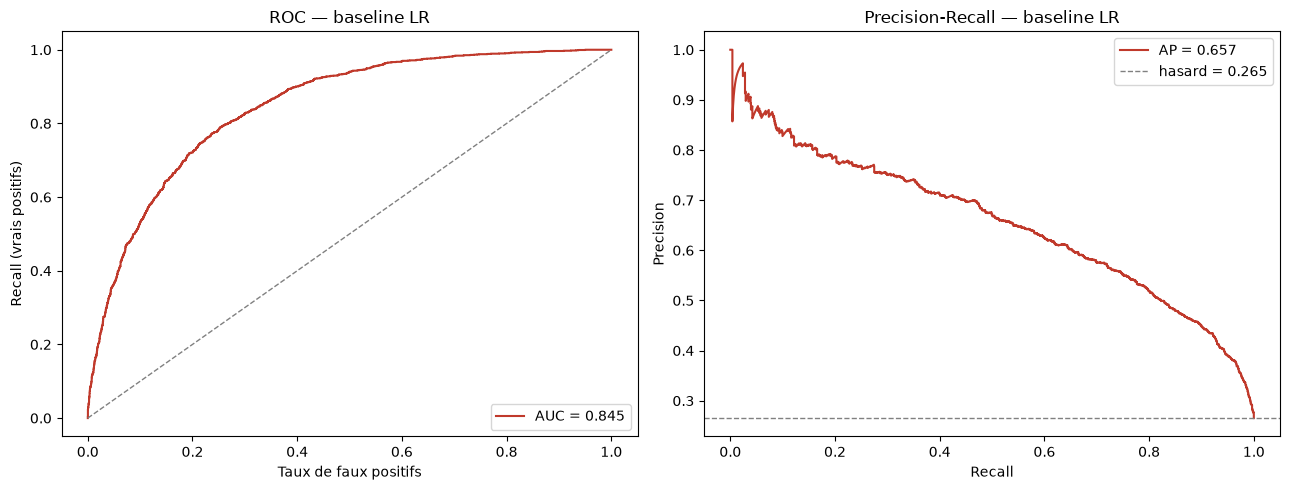

In [12]:
# 5.2 — Évaluation détaillée de la baseline (prédictions cross-validées, test toujours intact)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             precision_recall_curve, roc_auc_score, average_precision_score)

# Probabilités out-of-fold : chaque client est prédit par un modèle qui ne l'a jamais vu en train.
proba_lr = cross_val_predict(pipe_lr, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

print("Matrice de confusion (seuil 0.5) :")
cm = confusion_matrix(y_train, pred_lr)
print(pd.DataFrame(cm, index=["réel No", "réel Yes"], columns=["préd No", "préd Yes"]), "\n")
print(classification_report(y_train, pred_lr, target_names=["No churn", "Churn"], digits=3))
print(f"ROC-AUC : {roc_auc_score(y_train, proba_lr):.3f}   |   "
      f"PR-AUC : {average_precision_score(y_train, proba_lr):.3f}")

# Courbes ROC et Precision-Recall
fpr, tpr, _ = roc_curve(y_train, proba_lr)
prec, rec, _ = precision_recall_curve(y_train, proba_lr)
auc, ap, base = roc_auc_score(y_train, proba_lr), average_precision_score(y_train, proba_lr), y_train.mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, color="#c0392b", label=f"AUC = {auc:.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
ax[0].set_xlabel("Taux de faux positifs"); ax[0].set_ylabel("Recall (vrais positifs)")
ax[0].set_title("ROC — baseline LR"); ax[0].legend(loc="lower right")

ax[1].plot(rec, prec, color="#c0392b", label=f"AP = {ap:.3f}")
ax[1].axhline(base, ls="--", color="grey", lw=1, label=f"hasard = {base:.3f}")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall — baseline LR"); ax[1].legend(loc="upper right")
fig.tight_layout()
plt.show()

### 5.3 XGBoost (déséquilibre par `scale_pos_weight`)

Pipeline avec `preprocessor_xgb` (encodage ordinal, sans scaling). `scale_pos_weight = n_neg / n_pos` sur le train (≈ 2.77) joue le rôle de `class_weight` pour les arbres. **Paramètres par défaut ici** — le tuning Optuna vient en 5.4. Même `StratifiedKFold` qu'en 5.1 pour une comparaison loyale.

In [13]:
# 5.3 — XGBoost dans un Pipeline (encodage ordinal, aucun scaling) ; déséquilibre via scale_pos_weight
from xgboost import XGBClassifier

# scale_pos_weight = négatifs / positifs, calculé sur le TRAIN uniquement.
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (train) = {scale_pos_weight:.3f}\n")

pipe_xgb = Pipeline([
    ("prep", preprocessor_xgb),
    ("model", XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss",
                            random_state=42, n_jobs=-1)),
])

# Même StratifiedKFold qu'en 5.1 -> comparaison directe avec la baseline.
cv_xgb = cross_validate(pipe_xgb, X_train, y_train, cv=cv, scoring=scoring)
print("XGBoost (paramètres par défaut + scale_pos_weight) — CV 5 plis (train), seuil 0.5\n")
for m in scoring:
    s = cv_xgb["test_" + m]
    print(f"  {labels[m]:<26} {s.mean():.3f} +/- {s.std():.3f}")

# Comparaison directe baseline vs XGBoost non tuné (mêmes plis)
comp = pd.DataFrame({
    "LR baseline":      [cv_res["test_" + m].mean() for m in scoring],
    "XGBoost (défaut)": [cv_xgb["test_" + m].mean() for m in scoring],
}, index=["recall", "precision", "f1", "roc_auc", "pr_auc"]).round(3)
print("\nComparaison (moyennes CV) :")
print(comp)

scale_pos_weight (train) = 2.769



XGBoost (paramètres par défaut + scale_pos_weight) — CV 5 plis (train), seuil 0.5

  Recall (churn)  <-- cible  0.658 +/- 0.023
  Precision (churn)          0.553 +/- 0.015
  F1 (churn)                 0.600 +/- 0.017
  ROC-AUC                    0.823 +/- 0.007
  PR-AUC                     0.626 +/- 0.015

Comparaison (moyennes CV) :
           LR baseline  XGBoost (défaut)
recall           0.801             0.658
precision        0.517             0.553
f1               0.628             0.600
roc_auc          0.846             0.823
pr_auc           0.660             0.626


### 5.4 Tuning XGBoost par Optuna

**Optuna en deux mots (pour ne pas l'utiliser en boîte noire).** C'est de l'**optimisation bayésienne** : au lieu de balayer une grille fixe (*grid search*) ou de tirer au hasard, Optuna construit au fil des essais un modèle probabiliste de *« quels hyperparamètres donnent une bonne PR-AUC ? »* (sampler **TPE** — Tree-structured Parzen Estimator) et concentre les essais suivants sur les régions prometteuses (compromis exploration / exploitation). Résultat : peu d'essais pour une bonne solution.

**Objectif optimisé : la PR-AUC** (`average_precision`), métrique **seuil-indépendante** adaptée à la classe positive en contexte déséquilibré. On NE règle PAS sur le recall (l'optimiser au seuil 0.5 est dégénéré : tout prédire positif → recall 1). Le préprocesseur est refit dans chaque pli → **aucune fuite** pendant la recherche. Espace : les 6 hyperparamètres du cahier (`max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`).

In [14]:
# 5.4 — Tuning XGBoost par Optuna (optimisation bayésienne), objectif PR-AUC
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)  # pas de log par essai

def objective(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 3, 9),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 200, 700),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }
    model = XGBClassifier(**params, scale_pos_weight=scale_pos_weight,
                          eval_metric="logloss", random_state=42, n_jobs=-1)
    pipe = Pipeline([("prep", preprocessor_xgb), ("model", model)])
    # Objectif = PR-AUC moyenne en CV. Le préprocesseur est refit par pli -> pas de fuite.
    return cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=False)  # ~1-2 min

print(f"Meilleure PR-AUC (CV) : {study.best_value:.4f}\n")
print("Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k:<18} {v}")

C:\Users\mokam\PycharmProjects\projet-churn-ml\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Meilleure PR-AUC (CV) : 0.6701

Meilleurs hyperparamètres :
  max_depth          3
  learning_rate      0.01310530682516645
  n_estimators       557
  subsample          0.8088746223418821
  colsample_bytree   0.9558225677864421
  min_child_weight   4


In [15]:
# 5.4 (suite) — modèle XGBoost réglé : ré-évaluation complète + comparaison à 3 modèles
pipe_xgb_best = Pipeline([
    ("prep", preprocessor_xgb),
    ("model", XGBClassifier(**study.best_params, scale_pos_weight=scale_pos_weight,
                            eval_metric="logloss", random_state=42, n_jobs=-1)),
])
cv_xgb_best = cross_validate(pipe_xgb_best, X_train, y_train, cv=cv, scoring=scoring)

print("XGBoost réglé — CV 5 plis (train), seuil 0.5\n")
for m in scoring:
    s = cv_xgb_best["test_" + m]
    print(f"  {labels[m]:<26} {s.mean():.3f} +/- {s.std():.3f}")

comp = pd.DataFrame({
    "LR baseline":      [cv_res["test_" + m].mean() for m in scoring],
    "XGBoost (défaut)": [cv_xgb["test_" + m].mean() for m in scoring],
    "XGBoost réglé":    [cv_xgb_best["test_" + m].mean() for m in scoring],
}, index=["recall", "precision", "f1", "roc_auc", "pr_auc"]).round(3)
print("\nComparaison (moyennes CV) :")
print(comp)

XGBoost réglé — CV 5 plis (train), seuil 0.5

  Recall (churn)  <-- cible  0.807 +/- 0.031
  Precision (churn)          0.518 +/- 0.016
  F1 (churn)                 0.631 +/- 0.019
  ROC-AUC                    0.849 +/- 0.011
  PR-AUC                     0.670 +/- 0.020

Comparaison (moyennes CV) :
           LR baseline  XGBoost (défaut)  XGBoost réglé
recall           0.801             0.658          0.807
precision        0.517             0.553          0.518
f1               0.628             0.600          0.631
roc_auc          0.846             0.823          0.849
pr_auc           0.660             0.626          0.670


## 6. Évaluation

Évaluation finale du modèle retenu (**XGBoost réglé**) et comparaison à la baseline. Métriques : ROC-AUC, PR-AUC, recall/precision/F1 sur la classe `Churn`, matrice de confusion.

### 6.1 Choix du seuil de décision (objectif métier `recall ≥ 0.80`)

Un seuil par défaut à 0.5 n'a aucune justification métier. Objectif explicite : **capturer au moins 80 % des vrais churners** (`recall ≥ 0.80`), et parmi tous les seuils qui respectent cette contrainte, retenir celui de **precision maximale** (limiter les fausses alertes). Plus défendable qu'une simple maximisation automatique du F1.

⚠️ **Anti-fuite** : le seuil est calé sur les prédictions **out-of-fold du train** (`cross_val_predict`, même `StratifiedKFold`), jamais sur le test. Le test reste intact pour la seule évaluation finale (§6.2).


Seuil retenu : 0.509
Au seuil retenu (OOF train) -> recall = 0.800 | precision = 0.521


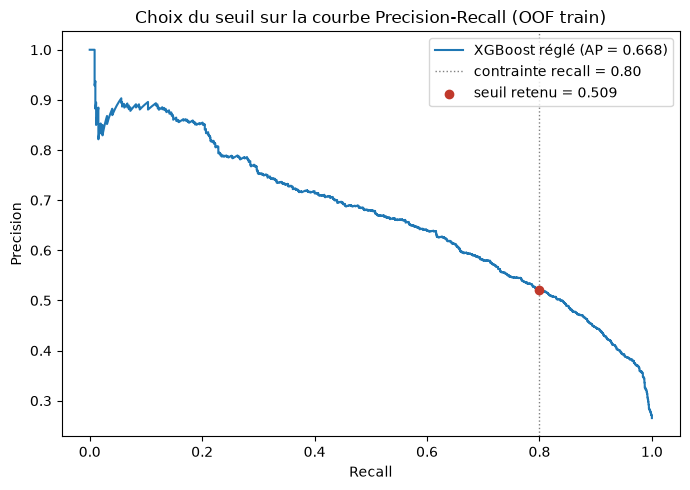

In [16]:
# 6.1 — Seuil : recall >= 0.80, precision maximale sous cette contrainte (calé sur l'OOF train)
import numpy as np

RECALL_MIN = 0.80

# Probabilités out-of-fold du XGBoost réglé : chaque client prédit par un modèle ne l'ayant pas vu.
proba_xgb_oof = cross_val_predict(pipe_xgb_best, X_train, y_train, cv=cv,
                                  method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y_train, proba_xgb_oof)
# precision_recall_curve : len(thr) = len(prec) - 1. On aligne prec/rec sur thr.
prec_t, rec_t = prec[:-1], rec[:-1]

mask = rec_t >= RECALL_MIN
best = np.where(mask)[0][np.argmax(prec_t[mask])]   # parmi recall>=0.80, precision max
threshold = thr[best]

print(f"Seuil retenu : {threshold:.3f}")
print(f"Au seuil retenu (OOF train) -> recall = {rec_t[best]:.3f} | precision = {prec_t[best]:.3f}")

# Visualisation : courbe PR du XGBoost réglé + point de fonctionnement retenu
ap = average_precision_score(y_train, proba_xgb_oof)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, color="#1f77b4", label=f"XGBoost réglé (AP = {ap:.3f})")
ax.axvline(RECALL_MIN, ls=":", color="grey", lw=1, label=f"contrainte recall = {RECALL_MIN:.2f}")
ax.scatter([rec_t[best]], [prec_t[best]], color="#c0392b", zorder=5,
           label=f"seuil retenu = {threshold:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Choix du seuil sur la courbe Precision-Recall (OOF train)")
ax.legend(loc="upper right")
fig.tight_layout(); plt.show()


### 6.2 Évaluation finale sur le test set

Le test (20 %, jamais touché jusqu'ici) sert **une seule fois**. Le XGBoost réglé est réentraîné sur l'intégralité du train, puis évalué sur le test au **seuil métier** fixé en §6.1. Le tableau comparatif final (baseline LR vs XGBoost à 0.5 vs XGBoost au seuil métier) est la pièce centrale du README.


In [17]:
# 6.2 — Évaluation finale sur le TEST set (intact jusqu'ici), au seuil métier de §6.1
from sklearn.metrics import recall_score, precision_score, f1_score

# Modèle retenu réentraîné sur tout le train, puis appliqué au test.
pipe_xgb_best.fit(X_train, y_train)
proba_test = pipe_xgb_best.predict_proba(X_test)[:, 1]
pred_05  = (proba_test >= 0.5).astype(int)
pred_thr = (proba_test >= threshold).astype(int)

print(f"XGBoost réglé — matrice de confusion sur le TEST (seuil métier {threshold:.3f}) :")
cm = confusion_matrix(y_test, pred_thr)
print(pd.DataFrame(cm, index=["réel No", "réel Yes"], columns=["préd No", "préd Yes"]), "\n")
print(classification_report(y_test, pred_thr, target_names=["No churn", "Churn"], digits=3))

# Baseline LR sur le test (seuil 0.5) pour la comparaison finale.
pipe_lr.fit(X_train, y_train)
proba_lr_test = pipe_lr.predict_proba(X_test)[:, 1]
pred_lr_test  = (proba_lr_test >= 0.5).astype(int)

def metrics_churn(y_true, proba, pred):
    return [recall_score(y_true, pred), precision_score(y_true, pred), f1_score(y_true, pred),
            roc_auc_score(y_true, proba), average_precision_score(y_true, proba)]

final = pd.DataFrame({
    "LR (seuil 0.5)":         metrics_churn(y_test, proba_lr_test, pred_lr_test),
    "XGBoost (seuil 0.5)":    metrics_churn(y_test, proba_test, pred_05),
    "XGBoost (seuil métier)": metrics_churn(y_test, proba_test, pred_thr),
}, index=["recall", "precision", "f1", "roc_auc", "pr_auc"]).round(3)

print("\nComparaison finale sur le TEST set :")
print(final)


XGBoost réglé — matrice de confusion sur le TEST (seuil métier 0.509) :
          préd No  préd Yes
réel No       756       279
réel Yes       79       295 

              precision    recall  f1-score   support

    No churn      0.905     0.730     0.809      1035
       Churn      0.514     0.789     0.622       374

    accuracy                          0.746      1409
   macro avg      0.710     0.760     0.715      1409
weighted avg      0.801     0.746     0.759      1409


Comparaison finale sur le TEST set :
           LR (seuil 0.5)  XGBoost (seuil 0.5)  XGBoost (seuil métier)
recall              0.783                0.797                   0.789
precision           0.504                0.513                   0.514
f1                  0.614                0.624                   0.622
roc_auc             0.842                0.846                   0.846
pr_auc              0.633                0.663                   0.663


## 7. Interprétabilité (SHAP)

Le XGBoost réglé est performant mais opaque. **SHAP** (valeurs de Shapley) attribue à chaque feature sa contribution **signée** à chaque prédiction (en log-odds), de façon additive et cohérente entre les niveaux local et global.

- **7.1 Global** : importance des features (`|SHAP|` moyen) + beeswarm (sens et amplitude de l'effet).
- **7.2 Local** : 2-3 prédictions individuelles décortiquées (waterfall).
- **7.3 Recoupement EDA** : cohérence entre les features importantes selon SHAP et les insights du Chi²/visualisations (§3) ; toute divergence est analysée, pas masquée.

> ⚠️ Pour XGBoost, les catégorielles sont **encodées en entiers ordinaux** (§4). La couleur du beeswarm (valeur faible → élevée) n'a donc **pas** de sens sémantique pour les variables nominales : on lit l'**amplitude** et le **signe** de l'effet, pas la couleur. Les valeurs réelles des clients expliqués sont affichées en clair en 7.2.


Importance globale — |SHAP| moyen (log-odds) :

Contract            0.791
tenure              0.459
MonthlyCharges      0.377
OnlineSecurity      0.263
TechSupport         0.209
PaymentMethod       0.132
PaperlessBilling    0.124
MultipleLines       0.092
TotalCharges        0.087
OnlineBackup        0.086
InternetService     0.066
StreamingMovies     0.059
Dependents          0.046
SeniorCitizen       0.037
StreamingTV         0.032
PhoneService        0.014
gender              0.013
DeviceProtection    0.005
Partner             0.002


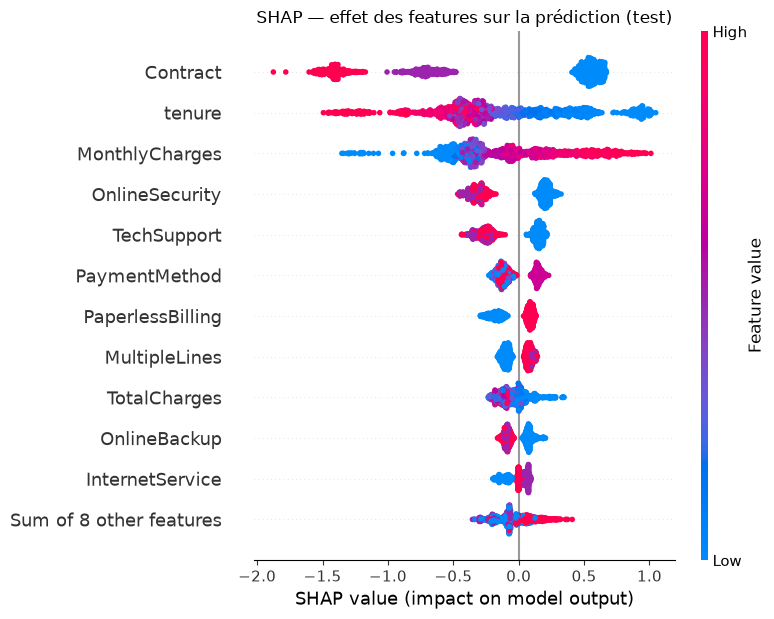

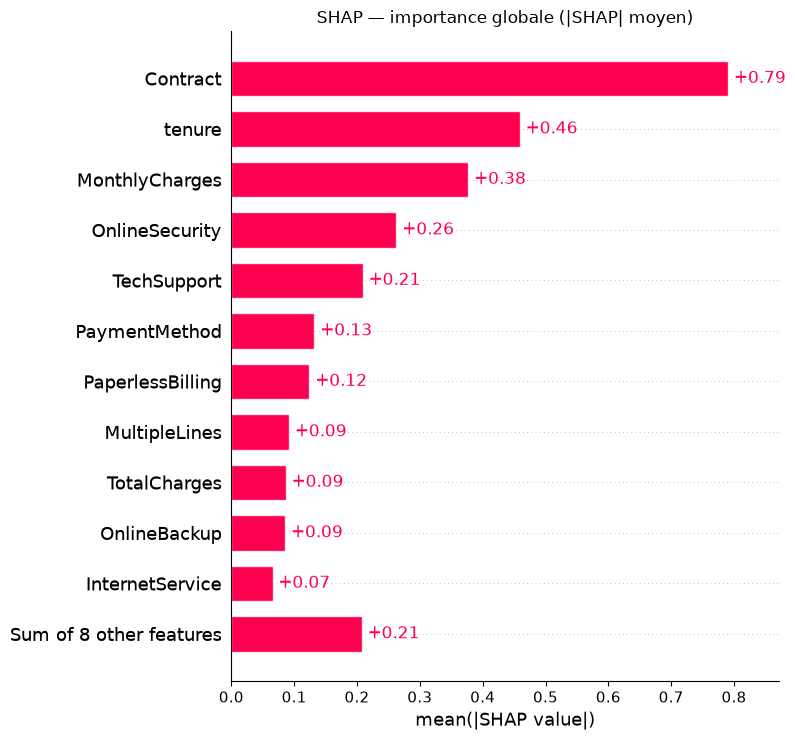

In [18]:
# 7.1 — SHAP global : TreeExplainer sur le XGBoost réglé, expliqué sur le TEST
import shap

# Modèle déjà entraîné en §6.2. On explique le test, transformé par le préprocesseur du pipeline.
prep  = pipe_xgb_best.named_steps["prep"]
model = pipe_xgb_best.named_steps["model"]

feat_names = num_features + cat_features        # ordre de sortie du ColumnTransformer (num puis cat)
Xte_enc = pd.DataFrame(prep.transform(X_test), columns=feat_names, index=X_test.index)

explainer = shap.TreeExplainer(model)
shap_exp  = explainer(Xte_enc)                  # Explanation : contributions en log-odds sur le test

# Importance globale = moyenne des |SHAP| par feature
imp = (pd.Series(np.abs(shap_exp.values).mean(axis=0), index=feat_names)
         .sort_values(ascending=False))
print("Importance globale — |SHAP| moyen (log-odds) :\n")
print(imp.round(3).to_string())

# Beeswarm : amplitude + dispersion de l'effet par client (couleur non sémantique pour les cat encodées)
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title("SHAP — effet des features sur la prédiction (test)")
plt.tight_layout(); plt.show()

# Barres : importance globale (|SHAP| moyen)
shap.plots.bar(shap_exp, max_display=12, show=False)
plt.title("SHAP — importance globale (|SHAP| moyen)")
plt.tight_layout(); plt.show()


### 7.2 Explications locales (waterfall)

Trois clients du test choisis pour leur valeur pédagogique : un **churner bien détecté** (vrai positif, proba la plus haute), un **fidèle bien classé** (vrai négatif, proba la plus basse) et une **fausse alerte** (faux positif, proba la plus haute parmi les non-churners). Chaque waterfall part de la valeur de base (log-odds moyen) et empile les contributions jusqu'à la prédiction du client.

Les valeurs sur le waterfall sont **encodées** (entiers ordinaux) ; le tableau qui suit affiche les **valeurs réelles** des trois clients pour une lecture métier directe.


=== Churner détecté (vrai positif) — proba churn = 0.958 | réel = Churn ===


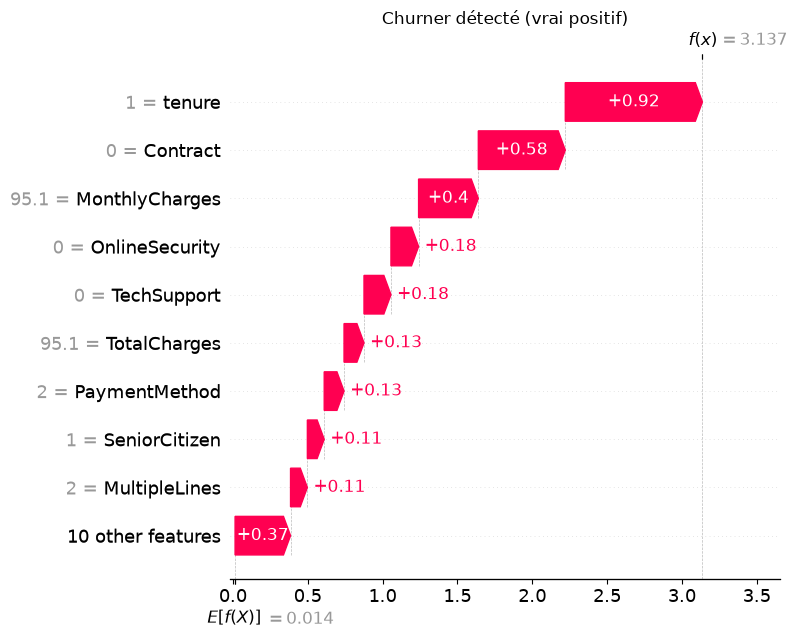

=== Client fidèle (vrai négatif) — proba churn = 0.011 | réel = No churn ===


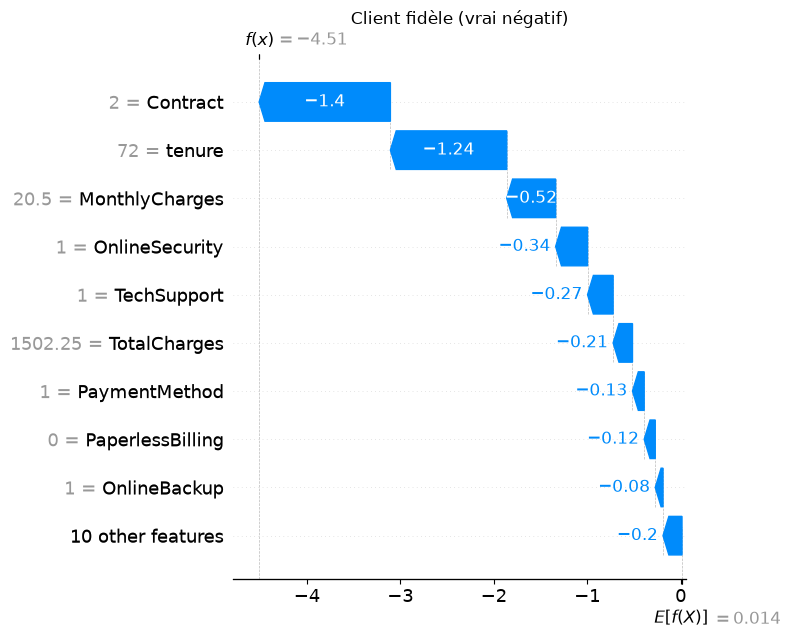

=== Fausse alerte (faux positif) — proba churn = 0.927 | réel = No churn ===


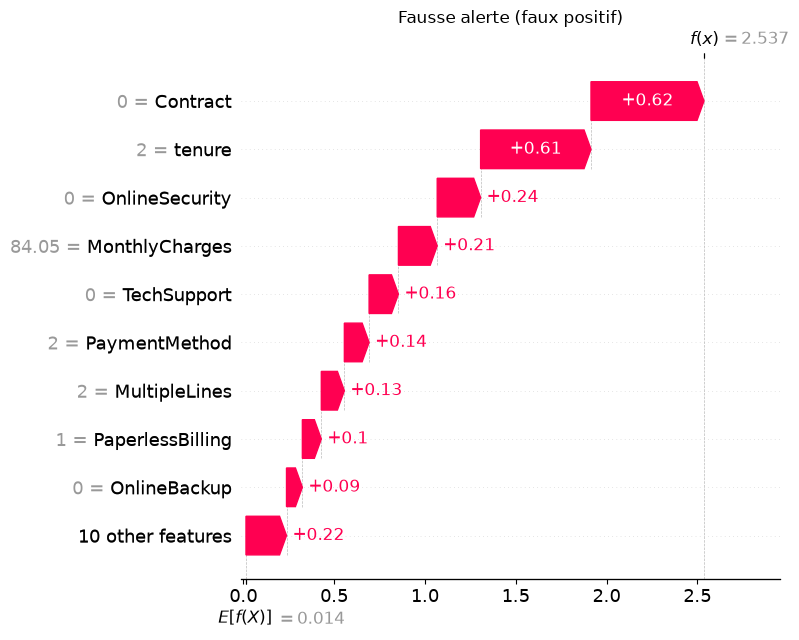


Valeurs réelles des clients expliqués :
                      vrai positif             vrai négatif      faux positif
gender                        Male                   Female            Female
SeniorCitizen                    1                        0                 1
Partner                        Yes                      Yes                No
Dependents                      No                       No                No
tenure                           1                       72                 2
PhoneService                   Yes                      Yes               Yes
MultipleLines                  Yes                       No               Yes
InternetService        Fiber optic                       No       Fiber optic
OnlineSecurity                  No      No internet service                No
OnlineBackup                    No      No internet service                No
DeviceProtection                No      No internet service                No
TechSupport            

In [19]:
# 7.2 — Explications locales : 3 clients du test (waterfall) + leurs valeurs réelles
# proba_test vient de §6.2. Positions entières dans X_test / Xte_enc.
pos = np.arange(len(X_test))
is_churn = (y_test.to_numpy() == 1)

i_tp = pos[is_churn][np.argmax(proba_test[is_churn])]     # churner le mieux détecté
i_tn = pos[~is_churn][np.argmin(proba_test[~is_churn])]   # fidèle le mieux classé
i_fp = pos[~is_churn][np.argmax(proba_test[~is_churn])]   # fidèle alerté à tort (proba la + haute)

cas = [("Churner détecté (vrai positif)", i_tp),
       ("Client fidèle (vrai négatif)",   i_tn),
       ("Fausse alerte (faux positif)",   i_fp)]

for titre, i in cas:
    reel = "Churn" if y_test.iloc[i] == 1 else "No churn"
    print(f"=== {titre} — proba churn = {proba_test[i]:.3f} | réel = {reel} ===")
    shap.plots.waterfall(shap_exp[i], max_display=10, show=False)
    plt.title(titre)
    plt.tight_layout(); plt.show()

# Valeurs réelles (non encodées) des trois clients expliqués
print("\nValeurs réelles des clients expliqués :")
print(X_test.iloc[[i_tp, i_tn, i_fp]].T
      .rename(columns={X_test.index[i_tp]: "vrai positif",
                       X_test.index[i_tn]: "vrai négatif",
                       X_test.index[i_fp]: "faux positif"}).to_string())


### 7.3 Recoupement avec l'EDA

Confrontation du classement SHAP (`|SHAP|` moyen, §7.1) aux insights du Chi² / V de Cramér (§3.3).

**Convergences fortes.**
1. **`Contract` domine partout** : 1er au SHAP (0.79) comme au V de Cramér (0.41). Le levier de rétention n°1 est confirmé par le modèle.
2. **`tenure` et `MonthlyCharges`** ressortent 2e (0.46) et 3e (0.38) au SHAP — exactement les deux marqueurs numériques que l'EDA pointait (faible ancienneté + facture élevée).
3. **Bloc sécurité/support partiellement confirmé** : `OnlineSecurity` (0.26) et `TechSupport` (0.21) sont 4e/5e, cohérent avec l'EDA.
4. **Variables non discriminantes confirmées** : `gender` (0.013) et `PhoneService` (0.014) sont en toute fin de classement — exactement les variables que le Chi² jugeait non significatives (p ≈ 0.49 et 0.34). Double validation, anti-biais « tout compte ».

**Divergences à analyser (le point intéressant).**
- **`DeviceProtection` et `OnlineBackup` s'effondrent** : forts au V de Cramér de l'EDA (≈ 0.28–0.35) mais quasi nuls au SHAP (0.005 et 0.086). Explication : ces variables partagent la modalité `"No internet service"` avec `OnlineSecurity`/`TechSupport`/`InternetService`. Leur signal est **redondant** ; XGBoost en concentre l'information sur quelques-unes (surtout `OnlineSecurity`) et ignore les autres. L'EDA univariée, elle, mesurait chaque variable **isolément** d'où des V de Cramér élevés mais trompeurs sur la contribution *marginale*. C'est précisément ce que SHAP révèle et que le Chi² ne peut pas voir.
- **`TotalCharges` faible au SHAP** (0.087, 9e) malgré une corrélation visible avec le churn : cohérent avec la note de §3.3 (corrélation mécanique avec `tenure`). Le modèle s'appuie sur `tenure` et délaisse `TotalCharges`, redondante.

**Lecture des cas locaux (§7.2).** Le faux positif est éclairant : `tenure = 2`, *month-to-month*, *fiber optic*, *electronic check*, facture élevée — **tous les marqueurs de risque** sont réunis, le modèle prédit churn à 0.93… mais ce client est resté. Le modèle ne se trompe pas « au hasard » : il se cale sur un profil de risque réel, et ce client est une exception légitime à ce profil. À l'inverse le vrai négatif (`tenure = 72`, contrat 2 ans) cumule tous les signaux de fidélité (proba 0.011).

> **Bilan** : SHAP confirme la hiérarchie de l'EDA sur les facteurs de tête et valide le rejet des variables inutiles, tout en **corrigeant** la sur-estimation univariée du bloc sécurité/support — un argument d'interprétabilité solide et défendable en entretien.
